# Extract ROI information [sim01]
Betas, T values, Z values

In [1]:
import os
import numpy as np
import pandas as pd
from nilearn.maskers import NiftiSpheresMasker

In [2]:
# Settings
data_dir = '/DATAPOOL/VPMB/BIDS-VPMB-SPE'
#fmriprep_dir = os.path.join(data_dir,'derivatives','fmriprep23','fmriprep')
nilearn_dir = os.path.join(data_dir,'derivatives','nilearn_glm')
#output_dir = os.path.join(data_dir,'derivatives','feedbackSimulator')
out_dir = '/DATAPOOL/home/alexandresayal/GitRepos/vpmb-tr/data'

subject_list = [x for x in os.listdir(data_dir) if 'sub-' in x]
subject_list.sort()

tr_list = [0.5, 0.75, 1, 2.5]
tr_label_list = ['0500','0750','1000','2500']
#n_volumes_list = [780, 520, 390, 156]
run_list = ['AA','UA']
#hrf_delay = 3 # in seconds

In [3]:
# Load subject-specific roi coordinates
roi_ss_coords = pd.read_csv(os.path.join(nilearn_dir,'group','roi_ss_matrix.txt'), sep='\t', header=None,
                            names=['left_mt_x','left_mt_y','left_mt_z','right_mt_x','right_mt_y','right_mt_z',
                                   'left_v1_x','left_v1_y','left_v1_z','right_v1_x','right_v1_y','right_v1_z'])

# add new column with the subject names
roi_ss_coords['subject'] = subject_list
roi_labels = ['hMT+ L', 'hMT+ R', 'V1 L', 'V1 R']

In [4]:
# Initialize matrix to store the beta values of all subjects per tr
BETAS = np.zeros((len(subject_list), len(tr_list), len(run_list), len(roi_labels)))
TVALS = np.zeros((len(subject_list), len(tr_list), len(run_list), len(roi_labels)))
ZVALS = np.zeros((len(subject_list), len(tr_list), len(run_list), len(roi_labels)))

In [5]:
# Create combinations of subject, tr and run
C = []
for ss,subject in enumerate(subject_list):
    # extract x,y,z coordinates of this subject's hMT+ roi
    cluster_coords = [[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0]]
    cluster_coords[0] = roi_ss_coords[roi_ss_coords['subject']==subject].iloc[:,0:3].values[0].tolist()
    cluster_coords[1] = roi_ss_coords[roi_ss_coords['subject']==subject].iloc[:,3:6].values[0].tolist()
    cluster_coords[2] = roi_ss_coords[roi_ss_coords['subject']==subject].iloc[:,6:9].values[0].tolist()
    cluster_coords[3] = roi_ss_coords[roi_ss_coords['subject']==subject].iloc[:,9:12].values[0].tolist()

    C.append([ss, subject, cluster_coords])

C

[[0, 'sub-01', [[-46, -70, 14], [46, -76, 6], [-10, -98, 0], [18, -96, 2]]],
 [1, 'sub-02', [[-50, -70, 14], [52, -68, 8], [-14, -98, 4], [14, -96, -8]]],
 [2, 'sub-03', [[-44, -62, 0], [48, -64, 0], [-4, -94, -6], [16, -82, -4]]],
 [3, 'sub-05', [[-46, -70, 8], [48, -64, 6], [-6, -92, -4], [18, -92, -8]]],
 [4, 'sub-06', [[-46, -66, 12], [48, -68, 6], [-12, -96, 2], [16, -96, 0]]],
 [5, 'sub-07', [[-46, -72, 4], [54, -66, 4], [-10, -88, -8], [20, -88, -4]]],
 [6, 'sub-08', [[-42, -78, 12], [46, -72, 4], [-8, -96, -4], [14, -86, -4]]],
 [7, 'sub-10', [[-46, -72, 0], [52, -66, 6], [-8, -90, -6], [16, -98, 0]]],
 [8, 'sub-11', [[-44, -76, -4], [50, -68, -8], [-18, -90, -8], [16, -84, -8]]],
 [9, 'sub-12', [[-42, -72, 2], [48, -72, 2], [-10, -98, -10], [16, -98, 0]]],
 [10, 'sub-15', [[-40, -80, -2], [50, -70, -4], [-6, -100, 6], [16, -94, 2]]],
 [11, 'sub-16', [[-40, -66, 6], [44, -62, 6], [-12, -100, 4], [16, -92, 2]]],
 [12, 'sub-21', [[-50, -66, 4], [52, -64, 8], [-14, -84, -10], [12,

In [6]:
for ss in range(len(subject_list)):
    print(f"Subject: {subject_list[ss]}")

    masker = NiftiSpheresMasker(
        seeds=C[ss][2],
        radius=6,
        detrend=False,
        standardize=False,
        low_pass=None,
        high_pass=None,
        resampling_target=None
        )
    
    masker.fit()

    for tr in range(len(tr_list)):
        for rr in range(len(run_list)):

            # contrast naming
            if run_list[rr] == "AA":
                contrast_name_valid = "AmbiguousMinusStatic"
            elif run_list[rr] == "UA":
                contrast_name_valid = "UnambiguousMinusStatic"

            beta_img = os.path.join(nilearn_dir,
                            f"{subject_list[ss]}_task-{run_list[rr]}_acq-{tr_label_list[tr]}_stat-beta_con-{contrast_name_valid}.nii.gz"
                            )
                        
            t_img = os.path.join(nilearn_dir,
                            f"{subject_list[ss]}_task-{run_list[rr]}_acq-{tr_label_list[tr]}_stat-t_con-{contrast_name_valid}.nii.gz"
                            )
            
            z_img = os.path.join(nilearn_dir,
                            f"{subject_list[ss]}_task-{run_list[rr]}_acq-{tr_label_list[tr]}_stat-z_con-{contrast_name_valid}.nii.gz"
                            )

            BETAS[ss,tr,rr,:] = masker.fit_transform(beta_img)[0]
            TVALS[ss,tr,rr,:] = masker.fit_transform(t_img)[0]
            ZVALS[ss,tr,rr,:] = masker.fit_transform(z_img)[0]

Subject: sub-01


KeyboardInterrupt: 

In [22]:
# save 4D matrices as npy files
np.save(os.path.join(out_dir,'BETAS.npy'), BETAS)
np.save(os.path.join(out_dir,'TVALS.npy'), TVALS)
np.save(os.path.join(out_dir,'ZVALS.npy'), ZVALS)

In [ ]:
# convert BETAS to a dataframe with the following columns: subject, tr, task, roi, beta
DF = pd.DataFrame(columns=['subject', 'tr', 'task', 'roi', 'beta', 'tval', 'zval'])
idx = 0
for ss,subject in enumerate(subject_list):
    for tt,tr in enumerate(tr_label_list):
        for ta,task in enumerate(run_list):
            for rr,roi in enumerate(roi_labels):
                beta = BETAS[ss,tt,ta,rr]
                tval = TVALS[ss,tt,ta,rr]
                zval = ZVALS[ss,tt,ta,rr]
                DF.loc[idx] = [subject, tr, task, roi, beta, tval, zval]
                idx += 1

In [ ]:
DF

In [ ]:
# save dataframe
DF.to_csv(os.path.join('..','data','nilearn-roianalysis-AAUA.tsv'), sep='\t', index=False)

# Load

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from statannotations.Annotator import Annotator

TRs = [500, 750, 1000, 2500]
TR_pairs = list(combinations(TRs, r=2))

roi_labels = ['hMT+ L', 'hMT+ R', 'V1 L', 'V1 R']
sns.set_theme(style="ticks")

In [2]:
# load dataframe
DF = pd.read_csv(os.path.join('..','data','nilearn-roianalysis-AAUA.tsv'), sep='\t')
DF

,subject,tr,task,roi,beta,tval,zval
0,sub-01,500,AA,hMT+ L,1.096810,8.331686,8.126074
1,sub-01,500,AA,hMT+ R,1.002429,6.197732,6.089277
2,sub-01,500,AA,V1 L,0.008337,0.022003,0.022026
3,sub-01,500,AA,V1 R,0.059216,0.455033,0.454662
4,sub-01,500,UA,hMT+ L,1.056252,8.718457,8.473065
...,...,...,...,...,...,...,...
475,sub-23,2500,AA,V1 R,-0.058794,-0.425742,-0.424228
476,sub-23,2500,UA,hMT+ L,0.419356,2.947624,2.800126
477,sub-23,2500,UA,hMT+ R,0.429989,3.431954,3.316117
478,sub-23,2500,UA,V1 L,0.268479,2.387647,2.342547


In [3]:
# Exclude all entries with task=AA
DF = DF[DF['task']=='UA']

In [4]:
roi_labels = ['hMT+', 'V1']

# "Average" 'roi'==hMT+ L and hMT+ R
DF.loc[DF['roi']=='hMT+ L', 'roi'] = 'hMT+'
DF.loc[DF['roi']=='hMT+ R', 'roi'] = 'hMT+'

# "Average" 'roi'==V1 L and V1 R
DF.loc[DF['roi']=='V1 L', 'roi'] = 'V1'
DF.loc[DF['roi']=='V1 R', 'roi'] = 'V1'

DF

,subject,tr,task,roi,beta,tval,zval
4,sub-01,500,UA,hMT+,1.056252,8.718457,8.473065
5,sub-01,500,UA,hMT+,0.985391,6.097818,6.000523
6,sub-01,500,UA,V1,0.303384,1.630034,1.626927
7,sub-01,500,UA,V1,0.310285,2.323704,2.316497
12,sub-01,750,UA,hMT+,0.876542,6.115048,5.975231
...,...,...,...,...,...,...,...
471,sub-23,1000,UA,V1,0.240939,2.951316,2.928709
476,sub-23,2500,UA,hMT+,0.419356,2.947624,2.800126
477,sub-23,2500,UA,hMT+,0.429989,3.431954,3.316117
478,sub-23,2500,UA,V1,0.268479,2.387647,2.342547


In [5]:
DF.groupby('tr')['beta'].mean()

tr
500     0.636357
750     0.599135
1000    0.634455
2500    0.615604
Name: beta, dtype: float64

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

500 vs. 750: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:4.941e-01 U_stat=5.680e+02
750 vs. 1000: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:1.000e+00 U_stat=4.450e+02
1000 vs. 2500: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:4.570e-02 U_stat=6.310e+02
500 vs. 1000: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:4.490e-01 U_stat=5.710e+02
750 vs. 2500: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:4.570e-02 U_stat=6.310e+02
500 vs. 2500: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:7.496e-05 U_stat=7.460e+02
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
    

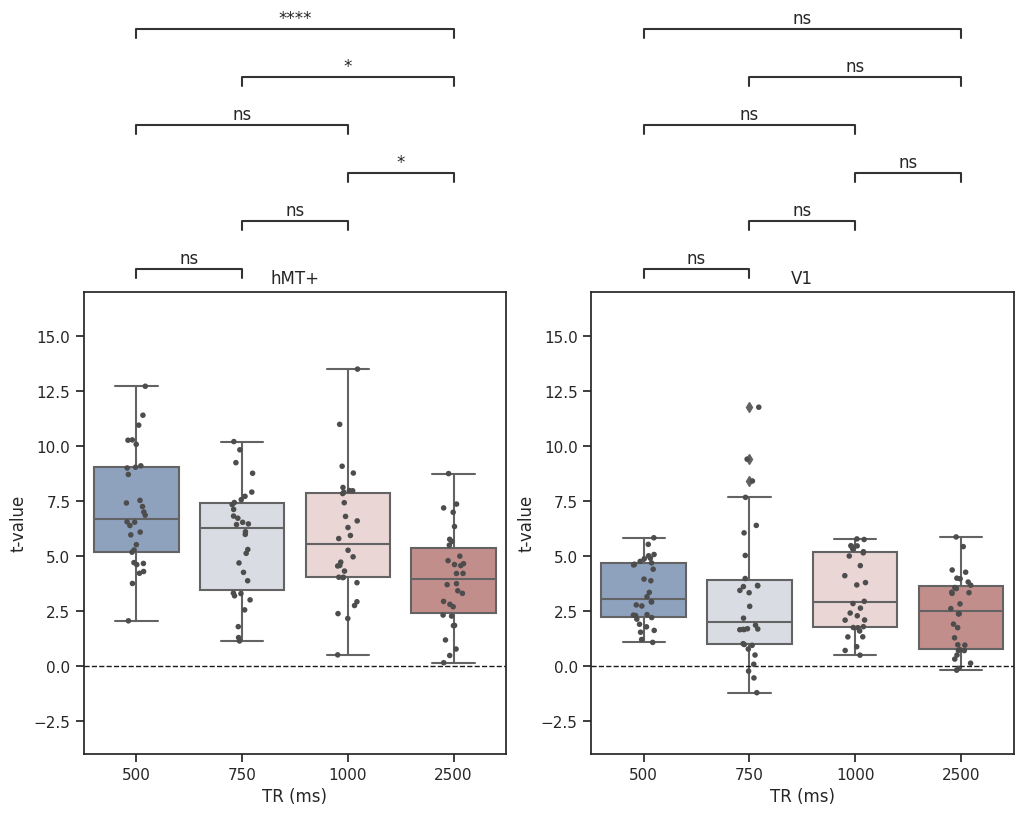

In [8]:
# perform a boxplot of the t values for each ROI, splitting per TR

fig,ax = plt.subplots(1,2,figsize=(12, 6))

for ii in range(2):

    # add points
    sns.stripplot(x="tr", y="tval", data=DF.loc[DF['roi'] == roi_labels[ii], :],size=4, color=".3", linewidth=0, ax=ax[ii])

    # boxplot
    aux = sns.boxplot(x = 'tr', y = 'tval', data=DF.loc[DF['roi'] == roi_labels[ii], :], palette="vlag", ax=ax[ii])
    aux.set_title(roi_labels[ii])
    aux.set_ylim(-4, 17)
    aux.set_ylabel('t-value')
    aux.set_xlabel('TR (ms)')

    # line in y=0
    ax[ii].axhline(y=0, color='k', linestyle='--', linewidth=1)

    # statistical comparisons between TRs
    annotator = Annotator(ax[ii], TR_pairs, data=DF.loc[DF['roi'] == roi_labels[ii], :], x='tr', y='tval', order=TRs)
    annotator.configure(test='Mann-Whitney', text_format='star', loc='outside', verbose=1, comparisons_correction='bonferroni')#, hide_non_significant=True,)
    annotator.apply_and_annotate()

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

500 vs. 750: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:1.000e+00 U_stat=4.810e+02
750 vs. 1000: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:1.000e+00 U_stat=4.510e+02
1000 vs. 2500: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:1.000e+00 U_stat=4.810e+02
500 vs. 1000: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:1.000e+00 U_stat=4.880e+02
750 vs. 2500: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:1.000e+00 U_stat=4.730e+02
500 vs. 2500: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:1.000e+00 U_stat=5.180e+02
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
    

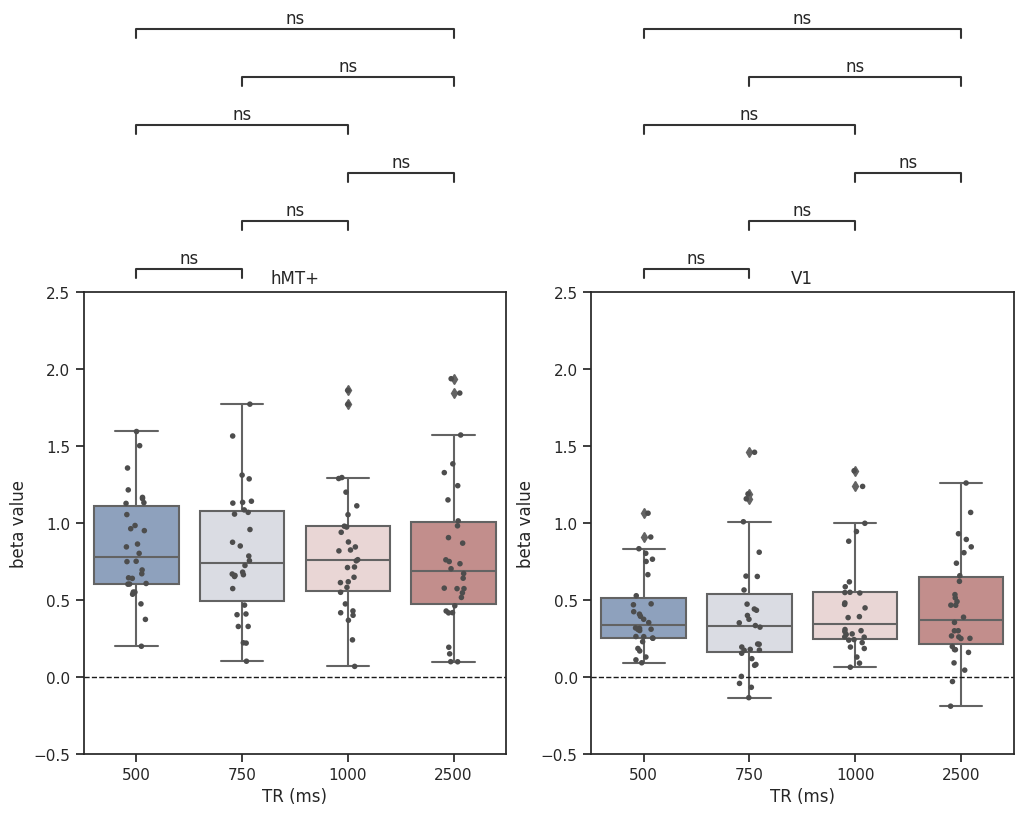

In [9]:
# perform a boxplot of the beta values for each ROI, splitting per TR

fig,ax = plt.subplots(1,2,figsize=(12, 6))

for ii in range(2):

    # add points
    sns.stripplot(x="tr", y="beta", data=DF.loc[DF['roi'] == roi_labels[ii], :],size=4, color=".3", linewidth=0, ax=ax[ii])

    # boxplot
    aux = sns.boxplot(x = 'tr', y = 'beta', data=DF.loc[DF['roi'] == roi_labels[ii], :], palette="vlag", ax=ax[ii])
    aux.set_title(roi_labels[ii])
    aux.set_ylim(-0.5, 2.5)
    aux.set_ylabel('beta value')
    aux.set_xlabel('TR (ms)')

    # line in y=0
    ax[ii].axhline(y=0, color='k', linestyle='--', linewidth=1)

    # statistical comparisons between TRs
    annotator = Annotator(ax[ii], TR_pairs, data=DF.loc[DF['roi'] == roi_labels[ii], :], x='tr', y='beta', order=TRs)
    annotator.configure(test='Mann-Whitney', text_format='star', loc='outside', verbose=1, comparisons_correction='bonferroni')
    annotator.apply_and_annotate()

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

500 vs. 750: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:3.687e-01 U_stat=5.770e+02
750 vs. 1000: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:1.000e+00 U_stat=4.530e+02
1000 vs. 2500: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:2.536e-02 U_stat=6.440e+02
500 vs. 1000: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:3.221e-01 U_stat=5.810e+02
750 vs. 2500: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:2.420e-02 U_stat=6.450e+02
500 vs. 2500: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:1.856e-05 U_stat=7.660e+02
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
    

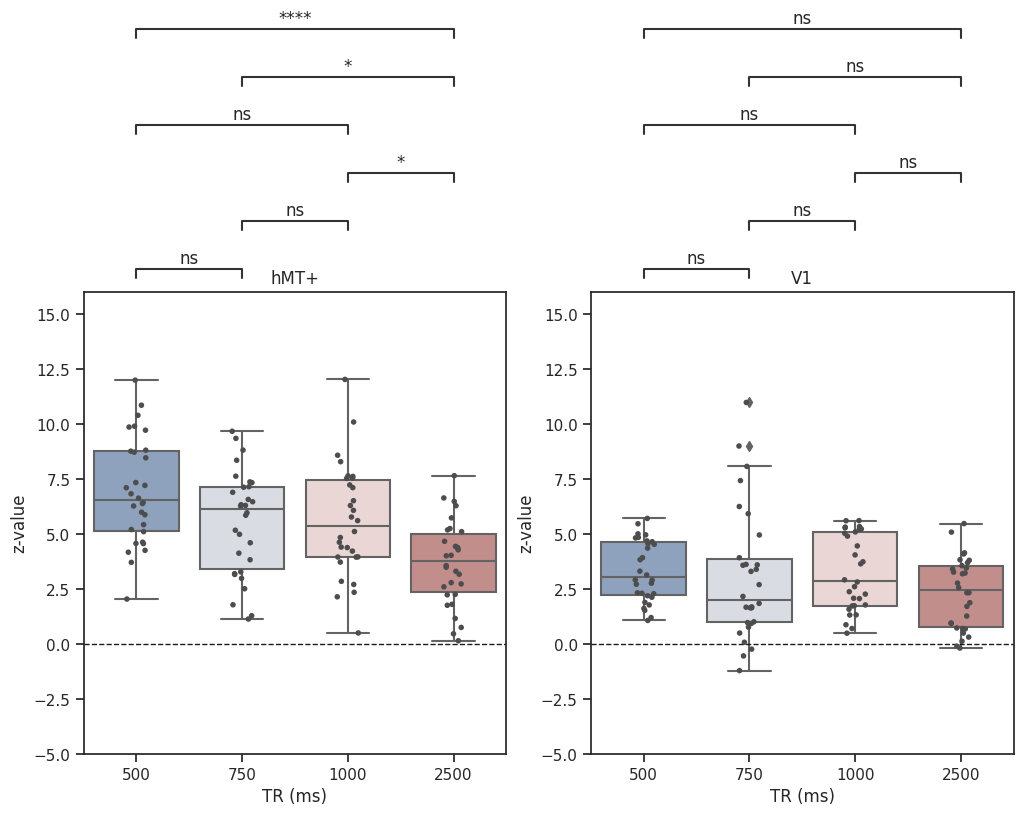

In [11]:
# perform a boxplot of the z values for each ROI, splitting per TR

fig,ax = plt.subplots(1,2,figsize=(12, 6))

for ii in range(2):

    # add points
    sns.stripplot(x="tr", y="zval", data=DF.loc[DF['roi'] == roi_labels[ii], :],size=4, color=".3", linewidth=0, ax=ax[ii])

    # boxplot
    aux = sns.boxplot(x = 'tr', y = 'zval', data=DF.loc[DF['roi'] == roi_labels[ii], :], palette="vlag", ax=ax[ii])
    aux.set_title(roi_labels[ii])
    aux.set_ylim(-5, 16)
    aux.set_ylabel('z-value')
    aux.set_xlabel('TR (ms)')

    # line in y=0
    ax[ii].axhline(y=0, color='k', linestyle='--', linewidth=1)

    # statistical comparisons between TRs
    annotator = Annotator(ax[ii], TR_pairs, data=DF.loc[DF['roi'] == roi_labels[ii], :], x='tr', y='zval', order=TRs)
    annotator.configure(test='Mann-Whitney', text_format='star', loc='outside', verbose=1, comparisons_correction='bonferroni')
    annotator.apply_and_annotate()